In [4]:
import geopandas
import rasterio
import matplotlib.pyplot as plt
from shapely.geometry import Point

In [11]:
# 2012
ml_prediction = rasterio.open("data/ICT_forest_output_2012_low.tif")
ground_truth = rasterio.open("data/2012_ICT_Boscos_390_2355_FINAL_CAT_COG.tif")
lulc = rasterio.open("data/2012_390.tif")

[Text(0.5, 1.0, 'Land Use Land Cover')]

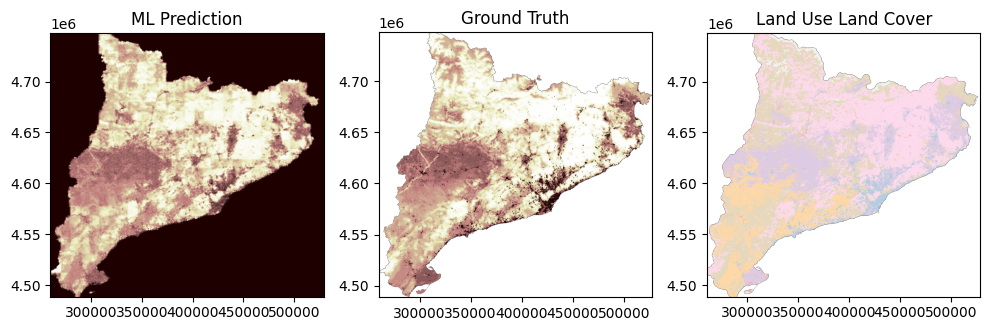

In [18]:
from rasterio.plot import show

fig, (ax1, ax2, ax3) = plt.subplots(ncols = 3, figsize = (12,12))

# transform rasterio plot to real world coords
src = ml_prediction
extent = [src.bounds[0], src.bounds[2], src.bounds[1], src.bounds[3]]
rasterio.plot.show(src, extent=extent, cmap="pink", ax = ax1)
ax1.set(title="ML Prediction")

src = ground_truth
extent = [src.bounds[0], src.bounds[2], src.bounds[1], src.bounds[3]]
rasterio.plot.show(src, extent=extent, cmap="pink", ax = ax2)
ax2.set(title="Ground Truth")

src = lulc
extent = [src.bounds[0], src.bounds[2], src.bounds[1], src.bounds[3]]
rasterio.plot.show(src, extent=extent, cmap="Pastel1", ax = ax3)
ax3.set(title="Land Use Land Cover")


In [13]:
import xarray as xr
import xrspatial
xrspatial.zonal.stats?

Signature:
xrspatial.zonal.stats(
    zones: xarray.core.dataarray.DataArray,
    values: xarray.core.dataarray.DataArray,
    zone_ids: Optional[List[Union[int, float]]] = None,
    stats_funcs: Union[Dict, List] = ['mean', 'max', 'min', 'sum', 'std', 'var', 'count'],
    nodata_values: Union[int, float] = None,
    return_type: str = 'pandas.DataFrame',
) -> Union[pandas.core.frame.DataFrame, dask.dataframe.dask_expr._collection.DataFrame, xarray.core.dataarray.DataArray]
Docstring:
Calculate summary statistics for each zone defined by a `zones`
dataset, based on `values` aggregate.

A single output value is computed for every zone in the input `zones`
dataset.

This function currently supports numpy backed, and dask with numpy backed
xarray DataArrays.

Parameters
----------
zones : xr.DataArray
    zones is a 2D xarray DataArray of numeric values.
    A zone is all the cells in a raster that have the same value,
    whether or not they are contiguous. The input `zones` raster defin